In [ ]:
# https://drive.google.com/file/d/1IHoMOnmA_TUGwBoUlQIAwb8nokqs5at8/view?usp=sharing

In [ ]:
pip install gdown

In [ ]:
# Download the zip file from Google Drive
import gdown
import os

file_id = '1IHoMOnmA_TUGwBoUlQIAwb8nokqs5at8'
output_filename = 'archive.zip'

gdown.download(id=file_id, output=output_filename, quiet=False)

Downloading...
From (original): https://drive.google.com/uc?id=1IHoMOnmA_TUGwBoUlQIAwb8nokqs5at8
From (redirected): https://drive.google.com/uc?id=1IHoMOnmA_TUGwBoUlQIAwb8nokqs5at8&confirm=t&uuid=a3f813cf-74a0-4836-8fe7-616415e8c79e
To: /content/archive.zip
100%|██████████| 1.27G/1.27G [00:12<00:00, 100MB/s]


'archive.zip'

In [ ]:
# Extract the contents of the zip file
import zipfile

if os.path.exists(output_filename):
    with zipfile.ZipFile(output_filename, 'r') as zip_ref:
        zip_ref.extractall('.') # Extract to the current directory
    print(f"Successfully extracted '{output_filename}'")
    # Optionally, remove the zip file after extraction
    # os.remove(output_filename)
else:
    print(f"Error: The file '{output_filename}' was not found.")

Successfully extracted 'archive.zip'


In [ ]:
# List the contents of the current directory to see extracted files
print("Contents of the current directory after extraction:")
print(os.listdir('.'))

Contents of the current directory after extraction:
['.config', 'archive.zip', 'dataset', 'sample_data']


splitting data

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

transformation

In [ ]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader, random_split

transform = transforms.Compose([
    transforms.Resize((110, 100)),
    transforms.RandomHorizontalFlip(),
    transforms.ToTensor(),
])

full_dataset = datasets.ImageFolder(root='dataset', transform=transform)

In [ ]:
train_size = int(0.7 * len(full_dataset))
val_size = len(full_dataset) - train_size

train_dataset, val_dataset = random_split(full_dataset, [train_size, val_size])

In [ ]:
train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

In [ ]:
num_classes = len(full_dataset.classes)
print(f"Number of classes in the dataset: {num_classes}")

Number of classes in the dataset: 4


In [ ]:
from collections import Counter

# Count classes in train_dataset
train_class_counts = Counter()
for _, labels in train_loader:
    train_class_counts.update(labels.cpu().numpy())

print("Number of images per class in Training Set:")
for class_idx, count in sorted(train_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

# Count classes in val_dataset
val_class_counts = Counter()
for _, labels in val_loader:
    val_class_counts.update(labels.cpu().numpy())

print("\nNumber of images per class in Validation Set:")
for class_idx, count in sorted(val_class_counts.items()):
    class_name = full_dataset.classes[class_idx]
    print(f"  Class {class_name} (ID: {class_idx}): {count} images")

Number of images per class in Training Set:
  Class broadleaf (ID: 0): 826 images
  Class grass (ID: 1): 2474 images
  Class soil (ID: 2): 2276 images
  Class soybean (ID: 3): 5159 images

Number of images per class in Validation Set:
  Class broadleaf (ID: 0): 365 images
  Class grass (ID: 1): 1046 images
  Class soil (ID: 2): 973 images
  Class soybean (ID: 3): 2217 images


MobilenetV2

In [ ]:
import torchvision.models as models
import torch.nn as nn

model = models.resnet50(pretrained=True)

# Freeze layers
for param in model.parameters():
    param.requires_grad = False

# Replace final layer
model.fc = nn.Sequential(
    nn.Linear(2048, 128),
    nn.ReLU(),
    nn.Dropout(0.3),
    nn.Linear(128, 4)
)

model = model.to("cuda")

/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /root/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 197MB/s]


Training loop

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.metrics import f1_score, precision_score, recall_score

# Define loss function and optimizer
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []

for epoch in range(10):
    # ---- TRAIN ----
    model.train()
    running_loss = 0
    correct = 0
    total = 0

    for images, labels in train_loader:
        images, labels = images.cuda(), labels.cuda()

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()

        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_losses.append(running_loss / len(train_loader))
    train_accuracies.append(correct / total)

    # ---- VALIDATION ----
    model.eval()
    val_loss = 0
    correct = 0
    total = 0

    all_preds = []
    all_labels = []

    with torch.no_grad():
        for images, labels in val_loader:
            images, labels = images.cuda(), labels.cuda()

            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item()

            _, predicted = torch.max(outputs, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()

            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    val_losses.append(val_loss / len(val_loader))
    val_accuracies.append(correct / total)

    # ---- F1, Precision, Recall ----
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    print(f"Epoch {epoch+1}")
    print(f"Train Loss: {train_losses[-1]:.4f}, Train Acc: {train_accuracies[-1]:.4f}")
    print(f"Val Loss: {val_losses[-1]:.4f}, Val Acc: {val_accuracies[-1]:.4f}")
    print(f"F1: {f1:.4f}, Precision: {precision:.4f}, Recall: {recall:.4f}")
    print("-"*40)

Epoch 1
Train Loss: 0.2670, Train Acc: 0.9067
Val Loss: 0.0972, Val Acc: 0.9685
F1: 0.9684, Precision: 0.9686, Recall: 0.9685
----------------------------------------
Epoch 2
Train Loss: 0.1267, Train Acc: 0.9580
Val Loss: 0.1541, Val Acc: 0.9424
F1: 0.9435, Precision: 0.9496, Recall: 0.9424
----------------------------------------
Epoch 3
Train Loss: 0.1178, Train Acc: 0.9598
Val Loss: 0.0902, Val Acc: 0.9689
F1: 0.9687, Precision: 0.9694, Recall: 0.9689
----------------------------------------
Epoch 4
Train Loss: 0.0965, Train Acc: 0.9661
Val Loss: 0.0742, Val Acc: 0.9748
F1: 0.9748, Precision: 0.9750, Recall: 0.9748
----------------------------------------
Epoch 5
Train Loss: 0.0952, Train Acc: 0.9650
Val Loss: 0.0825, Val Acc: 0.9711
F1: 0.9708, Precision: 0.9718, Recall: 0.9711
----------------------------------------
Epoch 6
Train Loss: 0.0920, Train Acc: 0.9663
Val Loss: 0.0681, Val Acc: 0.9776
F1: 0.9775, Precision: 0.9775, Recall: 0.9776
---------------------------------------

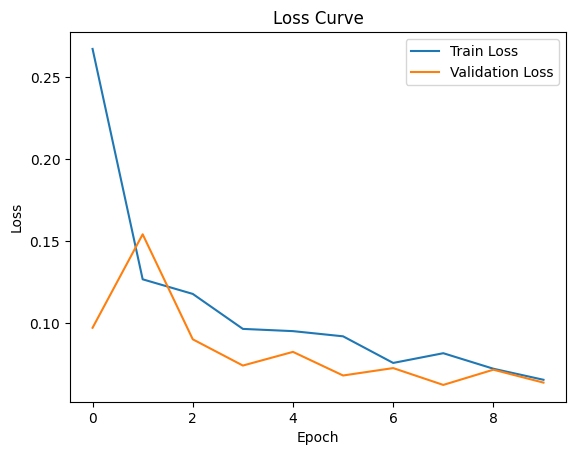

In [ ]:
import matplotlib.pyplot as plt

plt.figure()
plt.plot(train_losses, label='Train Loss')
plt.plot(val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

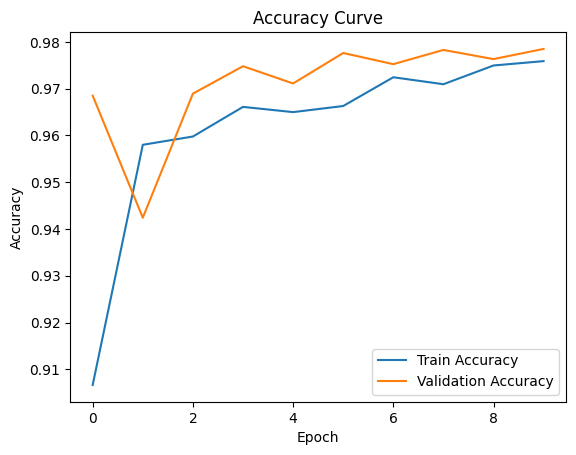

In [ ]:
plt.figure()
plt.plot(train_accuracies, label='Train Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

In [ ]:
f1 = f1_score(all_labels, all_preds, average='weighted')
precision = precision_score(all_labels, all_preds, average='weighted')
recall = recall_score(all_labels, all_preds, average='weighted')

print("Final Results:")
print("F1 Score:", f1)
print("Precision:", precision)
print("Recall:", recall)

Final Results:
F1 Score: 0.9784720799755209
Precision: 0.9786084142905613
Recall: 0.9784829384916323


### Test Model on a Single Image

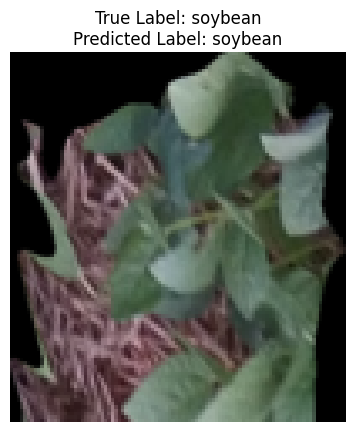

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Get a batch of validation images and labels
dataiter = iter(val_loader)
images, labels = next(dataiter)

# Take the first image from the batch for testing
image = images[0]
label = labels[0]

# Move image to GPU and add a batch dimension
image_gpu = image.unsqueeze(0).cuda()

# Make prediction
model.eval() # Set model to evaluation mode
with torch.no_grad():
    output = model(image_gpu)
    _, predicted = torch.max(output.data, 1)

# Convert image to numpy for plotting (permute dimensions from C, H, W to H, W, C)
img_np = image.cpu().numpy().transpose((1, 2, 0))

# Unnormalize if necessary (if you had a Normalize transform in your `transform`)
# For simplicity, assuming values are already in [0, 1] range after ToTensor

# Display the image and results
plt.imshow(img_np)
plt.title(f"True Label: {full_dataset.classes[label.item()]}\nPredicted Label: {full_dataset.classes[predicted.item()]}")
plt.axis('off')
plt.show()
